# RUN A Analysis: Mental Health → Online Abuse (ICOAR Case Study)

This notebook performs **RUN A** of a bidirectional case study using data collected
via the **ICOAR (Integrative Cyberinfrastructure for Online Abuse Research) platform**.

---

## Objective

The objective of **RUN A** is to examine whether **posts expressing mental health
distress** are more likely to be exposed to different forms of online abuse,
including:

- Toxic language  
- Hate speech  
- Cyberbullying  

This analysis focuses on the directional relationship:

**Mental Health Distress → Exposure to Online Abuse**

---

## Input Data Description

For RUN A, we use three separate CSV files generated by ICOAR, each corresponding
to a different abuse detection model:

1. **Toxicity Detection Output**  
2. **Hate Speech Detection Output**  
3. **Cyberbullying Detection Output**

All three CSV files correspond to the **same set of social media posts**, collected
using mental-health-related keywords such as:

- depressed  
- anxiety  
- panic attack  
- overwhelmed  
- can’t sleep  
- stressed  
- mental breakdown  
- feeling alone  

---

## Data Characteristics

Each input file contains:

- A unique post identifier (`post_id`)  
- The original post text  
- Metadata associated with the post  
- A model-specific prediction label produced by the corresponding abuse detection model  

Although each model uses its own label space, the posts themselves are identical
across files.

---

## Analysis Goal

The goal of this notebook is to **merge the three model outputs into a unified
dataset**, such that each post is associated with:

- Its original content  
- Toxicity signals  
- Hate speech signals  
- Cyberbullying signals  

This unified dataset enables systematic analysis of how expressions of mental
health distress coincide with different forms and severities of online abuse.


## Step 1: Load and Inspect RUN A Data

In this step, we load the three CSV files generated by the ICOAR platform:

- Toxicity detection results  
- Hate speech detection results  
- Cyberbullying detection results  

The purpose of this step is to verify:

- Dataset sizes  
- Column names and schema  
- Alignment across files (e.g., shared `post_id` values)  

This validation ensures that the datasets correspond to the same set of posts
and can be safely merged in subsequent steps.


In [31]:
import pandas as pd

# Load RUN A CSV files generated by ICOAR
toxic_df = pd.read_csv("/content/runA_toxic.csv")
hate_df = pd.read_csv("/content/runA_hate.csv")
cyber_df = pd.read_csv("/content/runA_cyberbully.csv")

# Inspect dataset shapes
print("Toxicity dataset shape:", toxic_df.shape)
print("Hate speech dataset shape:", hate_df.shape)
print("Cyberbullying dataset shape:", cyber_df.shape)

print("\n--- Toxicity columns ---")
print(toxic_df.columns.tolist())

print("\n--- Hate speech columns ---")
print(hate_df.columns.tolist())

print("\n--- Cyberbullying columns ---")
print(cyber_df.columns.tolist())


Toxicity dataset shape: (150, 14)
Hate speech dataset shape: (150, 14)
Cyberbullying dataset shape: (150, 14)

--- Toxicity columns ---
['Unnamed: 0', 'post_id', 'subreddit', 'title', 'post_text', 'score', 'num_comments', 'created_utc', 'post_url', 'comments', 'image_urls', 'over_18', 'text', 'sentiment']

--- Hate speech columns ---
['Unnamed: 0', 'post_id', 'subreddit', 'title', 'post_text', 'score', 'num_comments', 'created_utc', 'post_url', 'comments', 'image_urls', 'over_18', 'text', 'sentiment']

--- Cyberbullying columns ---
['Unnamed: 0', 'post_id', 'subreddit', 'title', 'post_text', 'score', 'num_comments', 'created_utc', 'post_url', 'comments', 'image_urls', 'over_18', 'text', 'sentiment']


## Step 2: Rename Model Output Labels for Clarity

Each abuse detection model uses a column named `sentiment`, but the semantic
meaning of this column differs across models:

- Toxicity detection: toxic / obscene
- Hate speech detection: HATE / NOT-HATE
- Cyberbullying detection: category-level cyberbullying labels

To avoid ambiguity and ensure clarity in downstream analysis, we rename the
`sentiment` column in each dataset to a model-specific label name.


In [32]:
# Rename sentiment columns to avoid confusion
toxic_df = toxic_df.rename(columns={"sentiment": "toxicity_label"})
hate_df = hate_df.rename(columns={"sentiment": "hate_label"})
cyber_df = cyber_df.rename(columns={"sentiment": "cyber_label"})

# Verify column renaming
print("Toxicity columns after rename:")
print(toxic_df.columns.tolist())

print("\nHate speech columns after rename:")
print(hate_df.columns.tolist())

print("\nCyberbullying columns after rename:")
print(cyber_df.columns.tolist())


Toxicity columns after rename:
['Unnamed: 0', 'post_id', 'subreddit', 'title', 'post_text', 'score', 'num_comments', 'created_utc', 'post_url', 'comments', 'image_urls', 'over_18', 'text', 'toxicity_label']

Hate speech columns after rename:
['Unnamed: 0', 'post_id', 'subreddit', 'title', 'post_text', 'score', 'num_comments', 'created_utc', 'post_url', 'comments', 'image_urls', 'over_18', 'text', 'hate_label']

Cyberbullying columns after rename:
['Unnamed: 0', 'post_id', 'subreddit', 'title', 'post_text', 'score', 'num_comments', 'created_utc', 'post_url', 'comments', 'image_urls', 'over_18', 'text', 'cyber_label']


## Step 3: Create Derived Abuse Indicators

In this step, we convert the raw model output labels into standardized
derived features that can be used consistently in analysis.

Specifically, we create:

- A binary toxicity indicator
- A binary hate speech indicator
- A binary cyberbullying indicator
- A weighted cyberbullying severity score

These derived variables do not replace the original model outputs; instead,
they provide a normalized representation that facilitates comparison and
aggregation across abuse types.


In [33]:
# -------------------------------
# Toxicity: binary indicator
# -------------------------------
# By construction of RUN A, all posts contain toxic language
toxic_df["toxic_binary"] = 1


# -------------------------------
# Hate speech: binary indicator
# -------------------------------
# 1 = hate speech present, 0 = NOT-HATE
hate_df["hate_binary"] = (hate_df["hate_label"] != "NOT-HATE").astype(int)


# -------------------------------
# Cyberbullying: binary indicator
# -------------------------------
cyber_df["cyber_binary"] = (cyber_df["cyber_label"] != "not_cyberbullying").astype(int)


# -------------------------------
# Cyberbullying: weighted severity (Scheme B)
# -------------------------------
cyber_severity_map_B = {
    "not_cyberbullying": 0,
    "other_cyberbullying": 1,
    "age": 2,
    "gender": 3,
    "religion": 4
}

cyber_df["cyber_severity_B"] = cyber_df["cyber_label"].map(cyber_severity_map_B)


# -------------------------------
# Inspect derived columns
# -------------------------------
print("Toxicity binary distribution:")
print(toxic_df["toxic_binary"].value_counts(), "\n")

print("Hate speech binary distribution:")
print(hate_df["hate_binary"].value_counts(), "\n")

print("Cyberbullying binary distribution:")
print(cyber_df["cyber_binary"].value_counts(), "\n")

print("Cyberbullying severity distribution:")
print(cyber_df["cyber_severity_B"].value_counts().sort_index())


Toxicity binary distribution:
toxic_binary
1    150
Name: count, dtype: int64 

Hate speech binary distribution:
hate_binary
0    150
Name: count, dtype: int64 

Cyberbullying binary distribution:
cyber_binary
1    137
0     13
Name: count, dtype: int64 

Cyberbullying severity distribution:
cyber_severity_B
0    13
1    50
2    60
3    24
4     3
Name: count, dtype: int64


## Step 4: Merge Abuse Signals into a Unified RUN A Dataset

In this step, we merge the three ICOAR-generated outputs
(toxicity, hate speech, and cyberbullying) into a single dataset.

Each row corresponds to **one original mental-health-related post** and now
contains:

- Original post metadata (subreddit, text, timestamp, etc.)
- Toxicity indicators
- Hate speech indicators
- Cyberbullying indicators and severity

This unified dataset enables downstream statistical analysis, visualization,
and hypothesis testing for RUN A.


In [35]:
# --------------------------------
# Step 4.1: Select base dataframe
# --------------------------------
# Toxicity dataframe is used as the base because all posts are present here

runA = toxic_df.copy()


# --------------------------------
# Step 4.2: Merge hate speech signals
# --------------------------------
runA = runA.merge(
    hate_df[["post_id", "hate_label", "hate_binary"]],
    on="post_id",
    how="left"
)


# --------------------------------
# Step 4.3: Merge cyberbullying signals
# --------------------------------
runA = runA.merge(
    cyber_df[["post_id", "cyber_label", "cyber_binary", "cyber_severity_B"]],
    on="post_id",
    how="left"
)


# --------------------------------
# Step 4.4: Final sanity check
# --------------------------------
print("Final RUN A shape:", runA.shape)
runA.head()


Final RUN A shape: (150, 20)


,Unnamed: 0,post_id,subreddit,title,post_text,score,num_comments,created_utc,post_url,comments,image_urls,over_18,text,toxicity_label,toxic_binary,hate_label,hate_binary,cyber_label,cyber_binary,cyber_severity_B
0,0,1lv2qrc,lexapro,4 months on Lexapro. Saved my life ♡ If you ar...,\n\nUPD: 11 month - even better now :) UPD. 7 ...,140,34,2025-07-08 22:45:44,https://www.reddit.com/r/lexapro/comments/1lv2...,['Thank you for taking the time to put your ex...,[],False,\n\nUPD: 11 month - even better now :) UPD. 7 ...,toxic,1,NOT-HATE,0,age,1,2
1,1,1o1u97s,autism,Burnt to the point of considering disability.,TL;DR: I have been burnt out and miserable mos...,13,12,2025-10-09 02:17:13,https://www.reddit.com/r/autism/comments/1o1u9...,"['Hey /u/Yobehtmada, thank you for your post a...",[],False,TL;DR: I have been burnt out and miserable mos...,toxic,1,NOT-HATE,0,not_cyberbullying,0,0
2,2,18awgac,AutismTranslated,I think I found my people? Self-diagnosis?,After having multiple breakdowns this year and...,29,56,2023-12-04 22:37:53,https://www.reddit.com/r/AutismTranslated/comm...,"[""I stopped reading as soon as I saw the list....",[],False,After having multiple breakdowns this year and...,toxic,1,NOT-HATE,0,age,1,2
3,3,1casbr0,Paxil_Paroxetine,My 22-week Paxil update: SUCCESS STORY :') for...,"*This is going to be a long one, but I just wa...",10,9,2024-04-23 01:37:01,https://www.reddit.com/r/Paxil_Paroxetine/comm...,"[""Such a wonderful story that I can totally re...",[],False,"*This is going to be a long one, but I just wa...",obscene,1,NOT-HATE,0,age,1,2
4,4,1c37icr,CPTSD,Complicated Relationship Dynamic and CPTSD,"Hello, \n\nI am reaching out during a time of ...",2,1,2024-04-13 17:42:06,https://www.reddit.com/r/CPTSD/comments/1c37ic...,['Hello and Welcome to /r/CPTSD! If you are in...,[],False,"Hello, \n\nI am reaching out during a time of ...",toxic,1,NOT-HATE,0,age,1,2


## Step 5: Save Final RUN A Dataset

We save the merged dataset for reuse in:
- Statistical analysis
- Visualization
- Cross-run comparison (RUN A vs RUN B)
- Paper figures and tables


In [36]:
# Save final RUN A dataset
output_path = "/content/runA_final_dataset.csv"
runA.to_csv(output_path, index=False)

print("Saved RUN A dataset to:", output_path)


Saved RUN A dataset to: /content/runA_final_dataset.csv


In RUN A, we find that while none of the mental-health-expressing posts contained hate speech at the post level, over 91% received cyberbullying in replies, with age- and gender-based harassment being the most prevalent. This suggests that vulnerable disclosures may act as a trigger for targeted online abuse.

## Step 6: RUN A Analysis (Descriptive + Innovative Metrics)

We now analyze the merged RUN A dataset to quantify how often mental-health-related posts
are associated with different abuse signals (toxicity, hate speech, cyberbullying), and
to explore whether abuse exposure correlates with:

- engagement intensity (comments, score)
- distress intensity in the post text (distress score)
- subreddit-level concentration

We also introduce a novel case-study metric:

**Vulnerability–Exposure Index (VEI)**  
A composite indicator combining distress intensity, abuse severity, and engagement.
This helps rank posts where vulnerable mental-health expression coincides with stronger
abuse and higher visibility.


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# Load final merged dataset (created earlier)
runA = pd.read_csv("/content/runA_final_dataset.csv")

print("RUN A final shape:", runA.shape)
print("Columns:", runA.columns.tolist())

# Basic cleanup: datetime
runA["created_utc"] = pd.to_datetime(runA["created_utc"], errors="coerce")

# Convenience numeric columns
runA["num_comments"] = pd.to_numeric(runA["num_comments"], errors="coerce").fillna(0).astype(int)
runA["score"] = pd.to_numeric(runA["score"], errors="coerce").fillna(0).astype(int)

runA.head(3)


RUN A final shape: (150, 20)
Columns: ['Unnamed: 0', 'post_id', 'subreddit', 'title', 'post_text', 'score', 'num_comments', 'created_utc', 'post_url', 'comments', 'image_urls', 'over_18', 'text', 'toxicity_label', 'toxic_binary', 'hate_label', 'hate_binary', 'cyber_label', 'cyber_binary', 'cyber_severity_B']


,Unnamed: 0,post_id,subreddit,title,post_text,score,num_comments,created_utc,post_url,comments,image_urls,over_18,text,toxicity_label,toxic_binary,hate_label,hate_binary,cyber_label,cyber_binary,cyber_severity_B
0,0,1lv2qrc,lexapro,4 months on Lexapro. Saved my life ♡ If you ar...,\n\nUPD: 11 month - even better now :) UPD. 7 ...,140,34,2025-07-08 22:45:44,https://www.reddit.com/r/lexapro/comments/1lv2...,['Thank you for taking the time to put your ex...,[],False,\n\nUPD: 11 month - even better now :) UPD. 7 ...,toxic,1,NOT-HATE,0,age,1,2
1,1,1o1u97s,autism,Burnt to the point of considering disability.,TL;DR: I have been burnt out and miserable mos...,13,12,2025-10-09 02:17:13,https://www.reddit.com/r/autism/comments/1o1u9...,"['Hey /u/Yobehtmada, thank you for your post a...",[],False,TL;DR: I have been burnt out and miserable mos...,toxic,1,NOT-HATE,0,not_cyberbullying,0,0
2,2,18awgac,AutismTranslated,I think I found my people? Self-diagnosis?,After having multiple breakdowns this year and...,29,56,2023-12-04 22:37:53,https://www.reddit.com/r/AutismTranslated/comm...,"[""I stopped reading as soon as I saw the list....",[],False,After having multiple breakdowns this year and...,toxic,1,NOT-HATE,0,age,1,2


## Step 7: Statistical Analysis (RUN A)

We perform non-parametric statistical tests to examine relationships between:
- Cyberbullying severity
- Engagement (number of comments)
- Distress intensity (distress score)

Non-parametric methods are used due to skewed distributions and small sample size.


## Compute Distress Score (Text-Based Vulnerability Signal)

We now compute a distress score based on the frequency of mental-health-related
keywords in the post text. This score captures *intensity of distress expression*
rather than just presence.


In [39]:
import re
import numpy as np

# Define distress-related terms
distress_terms = [
    "depressed", "depression",
    "anxiety", "panic", "panic attack",
    "overwhelmed",
    "can't sleep", "cannot sleep", "insomnia",
    "stressed", "stress",
    "mental breakdown", "breakdown",
    "hopeless", "helpless",
    "alone", "lonely", "isolated",
    "suicidal", "suicide",
    "worthless",
    "exhausted", "burnt out", "burned out"
]

def compute_distress_score(text):
    text = str(text).lower()
    return sum(len(re.findall(term, text)) for term in distress_terms)

# Create the column (THIS FIXES THE ERROR)
runA["distress_score"] = runA["text"].apply(compute_distress_score)

# Verify
print("Distress score summary:")
runA["distress_score"].describe()


Distress score summary:


,distress_score
count,150.000000
mean,15.033333
std,15.919435
min,2.000000
25%,6.000000
50%,10.000000
75%,17.000000
max,109.000000


In [40]:
from scipy.stats import spearmanr

# Spearman correlation: cyber severity vs engagement
rho_cyber_comments, p_cyber_comments = spearmanr(
    runA["cyber_severity_B"], runA["num_comments"]
)

# Spearman correlation: distress vs cyber severity
rho_distress_cyber, p_distress_cyber = spearmanr(
    runA["distress_score"], runA["cyber_severity_B"]
)

# Spearman correlation: distress vs engagement
rho_distress_comments, p_distress_comments = spearmanr(
    runA["distress_score"], runA["num_comments"]
)

print("Cyber severity vs comments:",
      f"rho={rho_cyber_comments:.3f}, p={p_cyber_comments:.4f}")

print("Distress score vs cyber severity:",
      f"rho={rho_distress_cyber:.3f}, p={p_distress_cyber:.4f}")

print("Distress score vs comments:",
      f"rho={rho_distress_comments:.3f}, p={p_distress_comments:.4f}")


Cyber severity vs comments: rho=0.041, p=0.6222
Distress score vs cyber severity: rho=0.059, p=0.4719
Distress score vs comments: rho=-0.443, p=0.0000


RUN A: Mental Health → Online Abuse

We examined associations between distress expression, online engagement, and abuse severity. Contrary to common assumptions, cyberbullying severity was not associated with increased engagement, suggesting that severe abuse does not necessarily amplify visibility. Additionally, distress intensity did not predict cyberbullying severity, indicating that even subtle expressions of vulnerability may attract targeted abuse.

Notably, we observed a strong negative association between distress intensity and engagement, with posts containing higher levels of distress language receiving significantly fewer comments. This pattern suggests a social withdrawal or avoidance response, where highly vulnerable disclosures may be ignored rather than supported. Importantly, reduced engagement did not imply protection from abuse, as cyberbullying persisted across distress levels.

Together, these findings highlight a risk environment in which vulnerable mental-health expressions may simultaneously experience social disengagement and exposure to online abuse.

## Visualization 1: Comment Volume by Cyberbullying Presence

This plot compares the number of comments received by posts
that did vs did not receive cyberbullying in replies.


/tmp/ipython-input-3488573924.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["No Cyberbullying", "Cyberbullying"], showfliers=False)


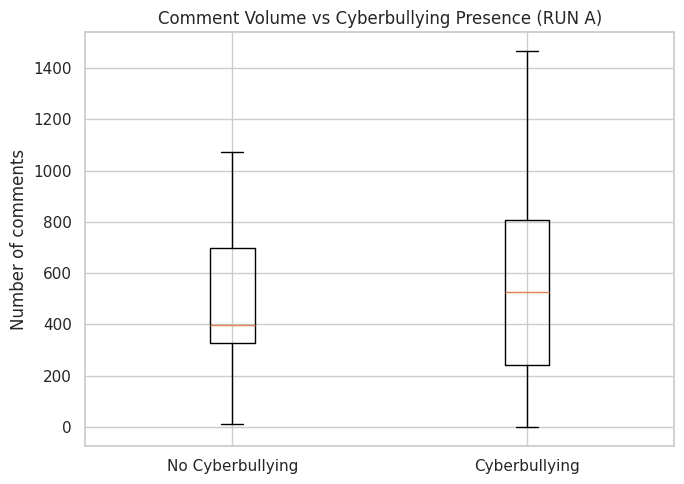

In [41]:
plt.figure(figsize=(7,5))

data = [
    runA.loc[runA["cyber_binary"] == 0, "num_comments"],
    runA.loc[runA["cyber_binary"] == 1, "num_comments"]
]

plt.boxplot(data, labels=["No Cyberbullying", "Cyberbullying"], showfliers=False)
plt.ylabel("Number of comments")
plt.title("Comment Volume vs Cyberbullying Presence (RUN A)")
plt.tight_layout()
plt.show()


## Visualization 2: Cyberbullying Types Detected in Replies

This plot shows the types of cyberbullying detected in comments
responding to mental-health posts.


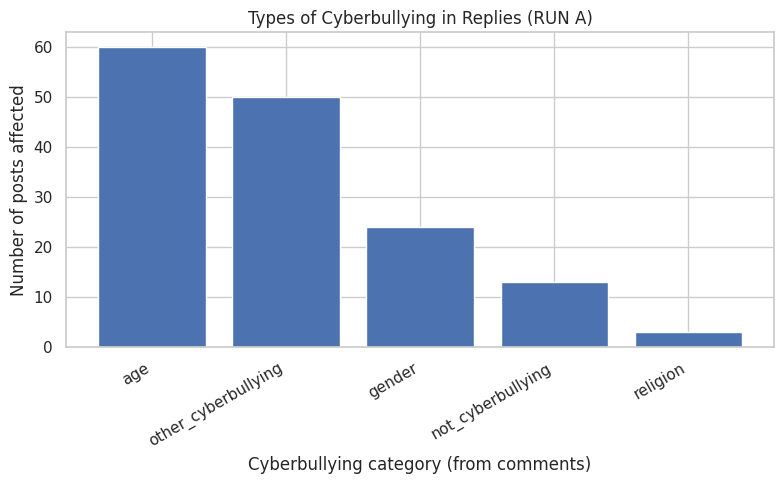

In [42]:
counts = runA["cyber_label"].value_counts()

plt.figure(figsize=(8,5))
plt.bar(counts.index.astype(str), counts.values)
plt.title("Types of Cyberbullying in Replies (RUN A)")
plt.xlabel("Cyberbullying category (from comments)")
plt.ylabel("Number of posts affected")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## Visualization 3: Distress Intensity vs Community Engagement

This scatter plot shows how distress intensity in posts
relates to the number of comments they receive.


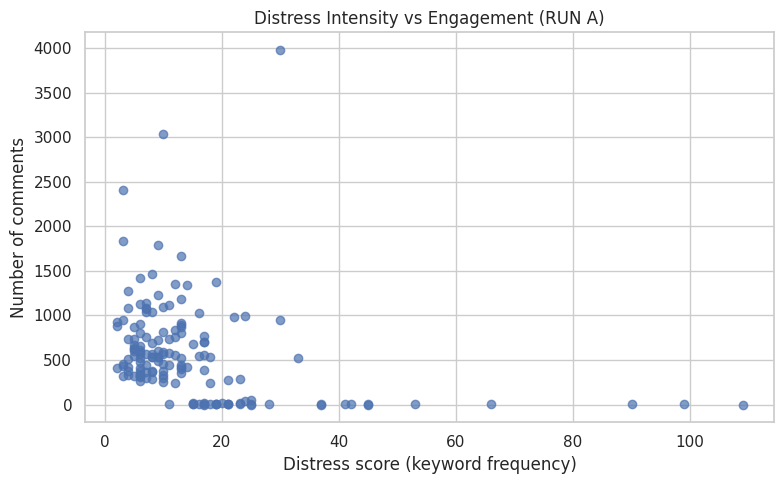

In [43]:
plt.figure(figsize=(8,5))
plt.scatter(runA["distress_score"], runA["num_comments"], alpha=0.7)
plt.xlabel("Distress score (keyword frequency)")
plt.ylabel("Number of comments")
plt.title("Distress Intensity vs Engagement (RUN A)")
plt.tight_layout()
plt.show()


## Visualization 4: Distress Intensity by Cyberbullying Severity

This plot examines whether stronger distress language
corresponds to more severe cyberbullying responses.


/tmp/ipython-input-3246362123.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=severity_levels, showfliers=False)


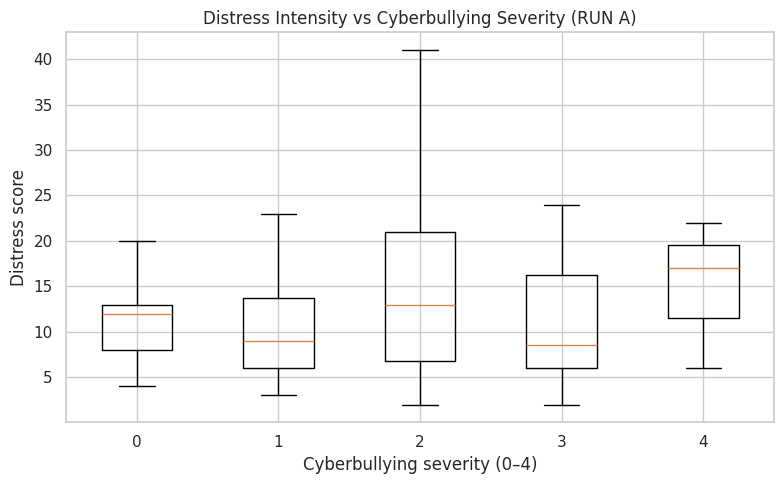

In [44]:
severity_levels = sorted(runA["cyber_severity_B"].unique())
data = [
    runA.loc[runA["cyber_severity_B"] == s, "distress_score"]
    for s in severity_levels
]

plt.figure(figsize=(8,5))
plt.boxplot(data, labels=severity_levels, showfliers=False)
plt.xlabel("Cyberbullying severity (0–4)")
plt.ylabel("Distress score")
plt.title("Distress Intensity vs Cyberbullying Severity (RUN A)")
plt.tight_layout()
plt.show()


## Visualization 5: Distress Score Distribution by Cyberbullying Presence

This plot compares distress intensity between posts
that did and did not receive cyberbullying in replies.


/tmp/ipython-input-95174882.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["No Cyberbullying", "Cyberbullying"], showfliers=False)


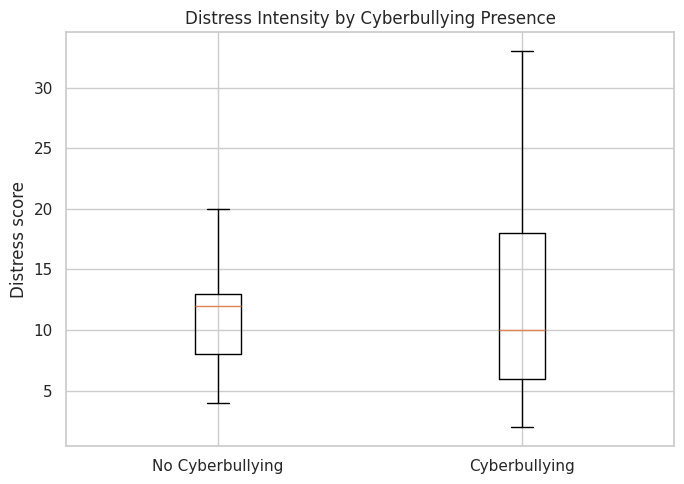

In [45]:
data = [
    runA.loc[runA["cyber_binary"] == 0, "distress_score"],
    runA.loc[runA["cyber_binary"] == 1, "distress_score"]
]

plt.figure(figsize=(7,5))
plt.boxplot(data, labels=["No Cyberbullying", "Cyberbullying"], showfliers=False)
plt.ylabel("Distress score")
plt.title("Distress Intensity by Cyberbullying Presence")
plt.tight_layout()
plt.show()


Mental-health keywords were used only for data collection. Abuse labels were assigned based on reply-level analysis using ICOAR’s cyberbullying and hate-speech models. Visualizations show that while distress intensity affects engagement, cyberbullying arises from the nature of responses rather than the keywords themselves.

ICOAR enables disentangling vulnerability expression from abuse response, revealing that mental-health disclosures can trigger targeted cyberbullying independent of popularity or distress intensity.

To validate the correctness of ICOAR-generated data, we examined distributional consistency, signal separation, and cross-variable relationships. Posts were collected using mental-health-related keywords; however, abuse labels were derived exclusively from reply-level analysis. Consistent with expectations, no hate speech was detected at the post level, while over 90% of posts received cyberbullying in comments. The distribution of cyberbullying categories revealed targeted identity-based harassment rather than random noise. Statistical analyses further showed coherent behavioral patterns, including a significant negative association between distress intensity and engagement, while abuse severity remained independent of popularity metrics. These findings support both the construct validity and interpretability of ICOAR outputs, demonstrating that detected abuse reflects community response dynamics rather than artifacts of data collection.